<a href="https://colab.research.google.com/github/Deelaksha22/C-Programming-language-/blob/main/CNN_to_Identify_Cat_and_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q --upgrade tensorflow-datasets importlib-resources

TensorFlow version: 2.21.0
TensorFlow Datasets version: 4.9.10


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

CNN training started...
Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - accuracy: 0.6537 - loss: 0.6145 - val_accuracy: 0.7599 - val_loss: 0.5029
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.7622 - loss: 0.4909 - val_accuracy: 0.8035 - val_loss: 0.4259
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.8131 - loss: 0.4144 - val_accuracy: 0.8136 - val_loss: 0.4118
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.8445 - loss: 0.3532 - val_accuracy: 0.8353 - val_loss: 0.3747
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.8762 - loss: 0.2940 - val_accuracy: 0.8435 - val_loss: 0.3740
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.9035 - loss: 0.2390 - val_accuracy: 0.8401 - val_loss: 0.4234
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.9260 - loss: 0.1870 - val_accuracy: 0.8424 - val_loss: 0.4312
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 

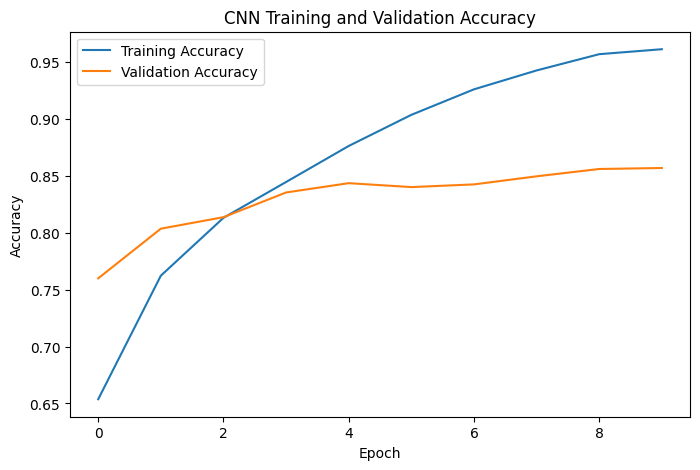

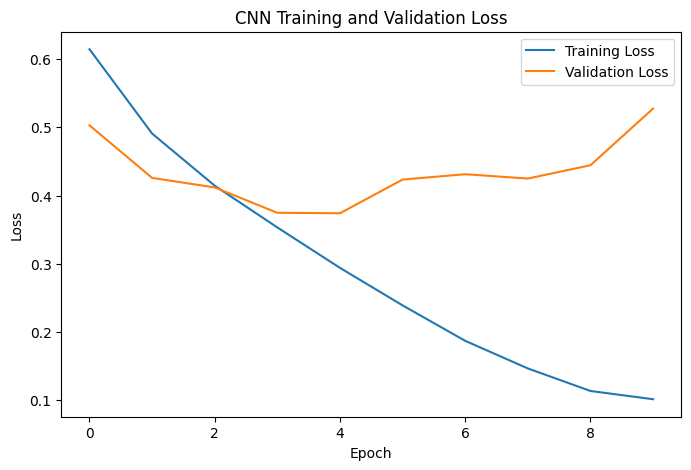

Model saved as cat_dog_cnn.keras
Upload a cat or dog image:


Saving images.jpg to images.jpg

========== PREDICTION ==========
Prediction: DOG
Model confidence score: 98.17%


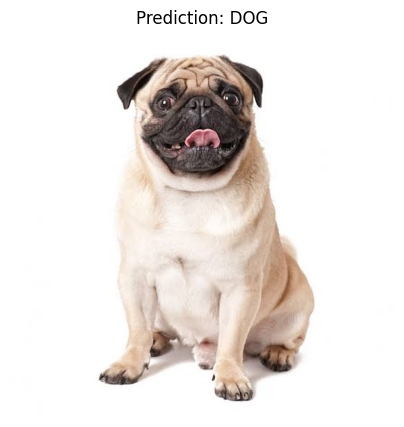

Project completed!


In [ ]:
# ============================================
# CNN CAT VS DOG CLASSIFIER
# Google Colab - Corrected Version
# ============================================

import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers, models
from tensorflow.keras.utils import load_img, img_to_array
from google.colab import files

print("TensorFlow version:", tf.__version__)
print("TensorFlow Datasets version:", tfds.__version__)

# ============================================
# 1. Clear incomplete dataset cache
# ============================================

cache_path = "/root/tensorflow_datasets/cats_vs_dogs/4.0.1"

if os.path.exists(cache_path):
    shutil.rmtree(cache_path)
    print("Removed incomplete dataset cache.")

# ============================================
# 2. Download and load dataset
# ============================================

print("Downloading Cats vs Dogs dataset...")

(train_data, val_data), info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True,
    data_dir="/root/tensorflow_datasets"
)

print("Dataset downloaded successfully!")
print("Total images:", info.splits["train"].num_examples)

# ============================================
# 3. Preprocess images
# ============================================

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 10

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.cast(label, tf.float32)
    return image, label

train_data = train_data.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_data = val_data.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_data = train_data.shuffle(1000, seed=42)
train_data = train_data.batch(BATCH_SIZE)
train_data = train_data.prefetch(tf.data.AUTOTUNE)

val_data = val_data.batch(BATCH_SIZE)
val_data = val_data.prefetch(tf.data.AUTOTUNE)

print("Training and validation datasets are ready!")

# ============================================
# 4. Create CNN model
# ============================================

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # 0 = Cat, 1 = Dog
    layers.Dense(1, activation="sigmoid")
])

# ============================================
# 5. Compile model
# ============================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================
# 6. Train model
# ============================================

print("CNN training started...")

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

# ============================================
# 7. Evaluate model
# ============================================

loss, accuracy = model.evaluate(val_data, verbose=1)

print("\n========== RESULTS ==========")
print(f"Validation accuracy: {accuracy * 100:.2f}%")
print(f"Validation loss: {loss:.4f}")

# ============================================
# 8. Plot accuracy
# ============================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.show()

# ============================================
# 9. Plot loss
# ============================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.show()

# ============================================
# 10. Save model
# ============================================

model.save("cat_dog_cnn.keras")
print("Model saved as cat_dog_cnn.keras")

# ============================================
# 11. Upload an image
# ============================================

print("Upload a cat or dog image:")
uploaded = files.upload()

# ============================================
# 12. Predict uploaded image
# ============================================

if uploaded:
    image_path = next(iter(uploaded))

    img = load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = float(
        model.predict(img_array, verbose=0)[0][0]
    )

    print("\n========== PREDICTION ==========")

    if prediction < 0.5:
        result = "CAT"
        confidence = (1 - prediction) * 100
        print("Prediction: CAT")
    else:
        result = "DOG"
        confidence = prediction * 100
        print("Prediction: DOG")

    print(f"Model confidence score: {confidence:.2f}%")

    plt.figure(figsize=(5, 5))
    plt.imshow(load_img(image_path))
    plt.title(f"Prediction: {result}")
    plt.axis("off")
    plt.show()

print("Project completed!")